# Scatter plots between density+SSS correlation and temperature

In [63]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import glob
import warnings
from pathlib import Path
import s3fs
import matplotlib
import gsw
import cmocean
import time

In [2]:
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [3]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:40453")
client

<Client: 'tcp://127.0.0.1:40453' processes=8 threads=32, memory=123.95 GiB>

## Open datasets

In [4]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [5]:
# initialize s3 filesystem
# for sassie s3 bucket
# s3_options = dict(anon=False, key=aws_credentials.access_key, secret=aws_credentials.secret_key)
# for ecco s3 bucket
s3_options = dict(anon=False)

In [6]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

In [7]:
# open SALT zarr store - [psu]
SALT_zarr = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options)

# open THETA zarr store - [degC]
THETA_zarr = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/THETA_AVG_DAILY.ZARR/', s3_options)

# open SIarea zarr store - [fraction of sea ice, 0 to 1]
SI_zarr = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', s3_options)

## Isolate open water

In [9]:
# select 7 years
SIarea_da = (SI_zarr.SIarea*100).sel(time=slice("2014","2020")) # convert to percentage
salt_da = SALT_zarr.SALT.sel(time=slice("2014","2020"))
theta_da = THETA_zarr.THETA.sel(time=slice("2014","2020"))

In [13]:
# select grid cells where SI conc is less than 15%
salt_openwater = salt_da.where(SIarea_da<15)
theta_openwater = theta_da.where(SIarea_da<15)

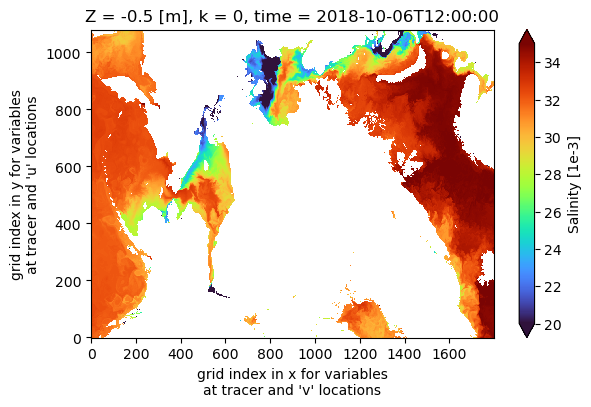

In [26]:
# check to make sure it looks right
salt_openwater.isel(time=1725,k=0).plot(figsize=[6.5,4],cmap='turbo',vmin=20,vmax=35);

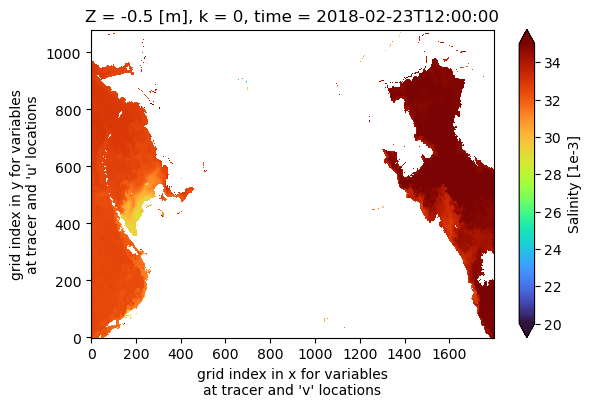

In [23]:
# check to make sure it looks right
salt_openwater.isel(time=1500,k=0).plot(figsize=[6.5,4],cmap='turbo',vmin=20,vmax=35);

### Calculate potential Density

In [30]:
# pressure from depth
# Z needs to be positive up
pressure_da = gsw.p_from_z(HH_grid.isel(k=[0,10,21]).Z, HH_grid.YC).compute()

In [31]:
# just double check to make sure they look reasonable
pressure_da.isel(i=10,j=10).values

array([  0.50428623,  21.30716931, 100.246103  ])

In [32]:
# Calculates Absolute Salinity from Practical Salinity
abs_salt = gsw.SA_from_SP(salt_openwater, pressure_da, HH_grid.XC, HH_grid.YC)

In [33]:
# Calculates Conservative Temperature of seawater from potential temperature (whose reference sea pressure is zero dbar)
cons_temp = gsw.CT_from_pt(abs_salt, theta_openwater)

In [34]:
# calculate potential density
dens_da = gsw.density.sigma0(abs_salt, cons_temp)

# change name and clear salinity attrs
dens_da.name = 'potential_density'
dens_da.attrs = ""

### Compute correlations

In [36]:
print(dens_da.isel(k=0).Z.values)
print(dens_da.isel(k=1).Z.values)

-0.5
-21.125


In [38]:
# calculate delta sigma
delta_sigma_20m = (dens_da.isel(k=0) - dens_da.isel(k=1))

In [68]:
# calculate correlation coefficients between SSS and delta sigma (0-20m)
corr_SSS_delta20m = xr.corr(abs_salt.isel(k=0).sel(time="2019-08"), delta_sigma_20m.sel(time="2019-08"), dim='time')

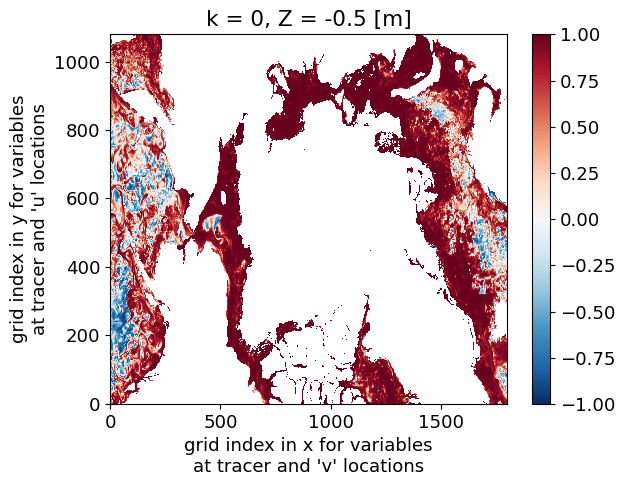

In [69]:
corr_SSS_delta20m.plot();

In [70]:
corr_SSS_delta20m_flat = corr_SSS_delta20m.values.flatten()
SST_flat = theta_openwater.isel(k=0).sel(time="2019-08").mean(dim='time').values.flatten()

In [71]:
print(corr_SSS_delta20m_flat.shape)
print(SST_flat.shape)

(1944000,)
(1944000,)


In [72]:
nan_mask = (~np.isnan(corr_SSS_delta20m_flat))

In [73]:
corr_SSS_delta20m_1D = corr_SSS_delta20m_flat[nan_mask]
SST_1D = SST_flat[nan_mask]

In [74]:
print(corr_SSS_delta20m_1D.shape)
print(SST_1D.shape)

(726041,)
(726041,)


Time taken to plot: 0.0017 minutes


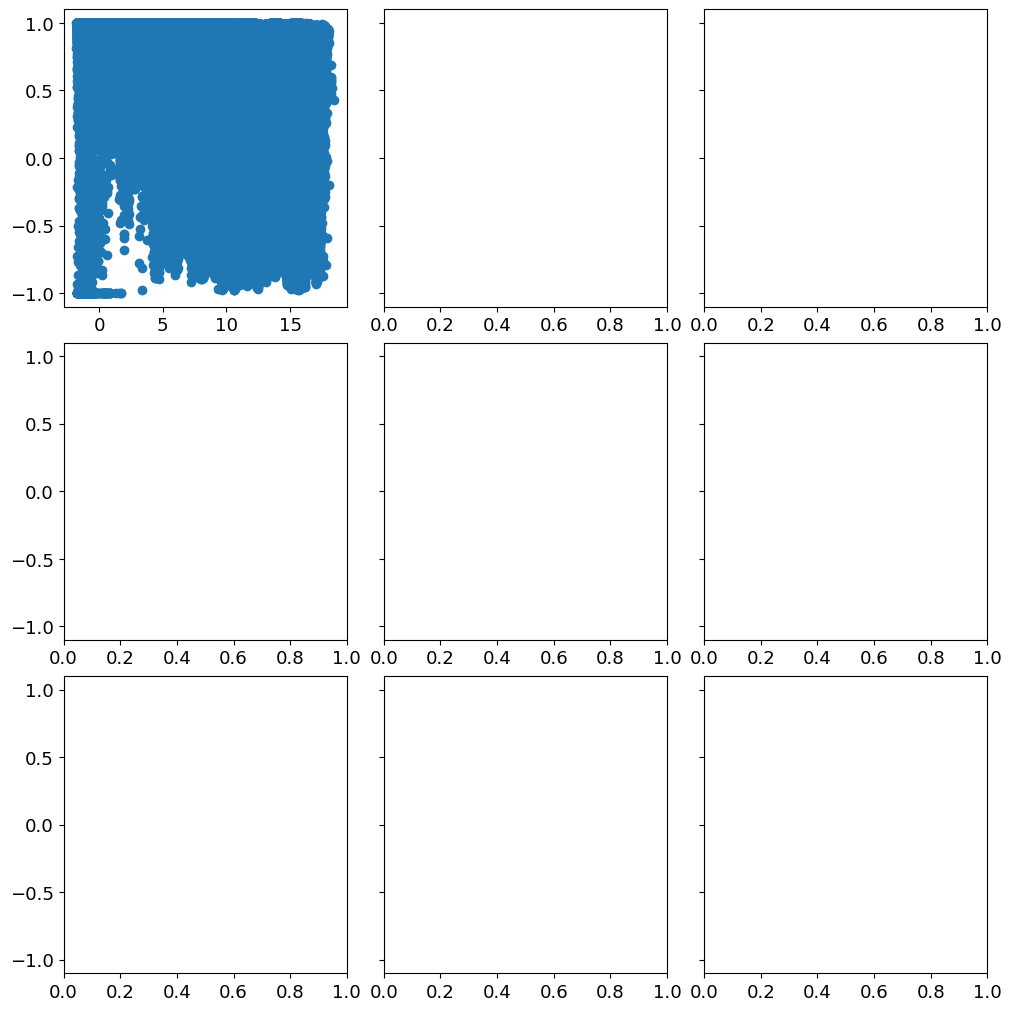

In [75]:
# Measure the time taken to plot
start_time = time.time()

plt.rcParams.update({'font.size': 13})

# plot max buoyancy freq by SSS, colored by SST
fig, ((ax1,ax2,ax3),(ax4,ax5,ax6),(ax7,ax8,ax9)) = plt.subplots(3,3,figsize=[10,10], sharey=True, layout='constrained')

# difference in density between surface and 20 m (surf-20)
ax1.scatter(SST_1D,corr_SSS_delta20m_1D);

# ax2.scatter(salt_august_avg.isel(k=0,year=1),delta_sigma_20m.isel(year=1),\
#             c=theta_august_avg.isel(k=0,year=1),cmap='turbo',vmin=-2,vmax=9);

# cbar_temp = ax3.scatter(salt_august_avg.isel(k=0,year=2),delta_sigma_20m.isel(year=2),\
#                         c=theta_august_avg.isel(k=0,year=2),cmap='turbo',vmin=-2,vmax=9);

# ax4.scatter(salt_august_avg.isel(k=0,year=3),delta_sigma_20m.isel(year=3),\
#             c=theta_august_avg.isel(k=0,year=3),cmap='turbo',vmin=-2,vmax=9);

# ax5.scatter(salt_august_avg.isel(k=0,year=4),delta_sigma_20m.isel(year=4),\
#             c=theta_august_avg.isel(k=0,year=4),cmap='turbo',vmin=-2,vmax=9);

# ax6.scatter(salt_august_avg.isel(k=0,year=5),delta_sigma_20m.isel(year=5),\
#             c=theta_august_avg.isel(k=0,year=5),cmap='turbo',vmin=-2,vmax=9);

# ax7.scatter(salt_august_avg.isel(k=0,year=6),delta_sigma_20m.isel(year=6),\
#             c=theta_august_avg.isel(k=0,year=6),cmap='turbo',vmin=-2,vmax=9);

# ax1.set_ylabel(r'$\Delta \sigma_{\theta}$ (kg m$^{-3}$)')
# ax4.set_ylabel(r'$\Delta \sigma_{\theta}$ (kg m$^{-3}$)')
# ax7.set_ylabel(r'$\Delta \sigma_{\theta}$ (kg m$^{-3}$)')

# # Make a colorbar for the ContourSet returned by the contourf call.
# cbar = fig.colorbar(cbar_temp,ax=ax3)
# cbar.ax.set_ylabel('Surface temperature ($\degree$C)');

# for ax in (ax1,ax2,ax3,ax4,ax5,ax6,ax7):
#     ax.grid(linestyle='dashed',color='gray',linewidth=0.5)
#     ax.set_xlim(0,35)
#     ax.set_xlabel("")

# ax7.set_xlabel("Surface salinity (g/kg)")
# ax5.set_xlabel("Surface salinity (g/kg)")
# ax6.set_xlabel("Surface salinity (g/kg)")
    
# # Turn off the axes we don't need
# ax8.set_axis_off()
# ax9.set_axis_off()

# # titles
# ax1.set_title(str(salt_august_avg.isel(year=0).year.values))
# ax2.set_title(str(salt_august_avg.isel(year=1).year.values))
# ax3.set_title(str(salt_august_avg.isel(year=2).year.values))
# ax4.set_title(str(salt_august_avg.isel(year=3).year.values))
# ax5.set_title(str(salt_august_avg.isel(year=4).year.values))
# ax6.set_title(str(salt_august_avg.isel(year=5).year.values))
# ax7.set_title(str(salt_august_avg.isel(year=6).year.values))

# plt.suptitle(r'SSS vs. $\Delta \sigma_{\theta}$ between surface and 20 m');

end_time = time.time()  # End timer

# Compute and display elapsed time
elapsed_time = (end_time - start_time) / 60
print(f"Time taken to plot: {elapsed_time:.4f} minutes")